# Motivation and Review of Thermodynamics

## Learning Goals

After going through these notes, students should be able to:

1. Explain what statistical mechanics is and why it is useful for chemistry, biophysics, and molecular simulation.
2. Distinguish microscopic states from macroscopic thermodynamic states.
3. State the first and second laws in differential form.
4. Use entropy maximization to explain the direction of spontaneous change.
5. Identify conjugate thermodynamic variables such as $T$ and $S$, $p$ and $V$, and $\mu_i$ and $n_i$.
6. Recognize why free energies arise from Legendre transforms.
7. Connect thermodynamic equilibrium conditions to the statistical mechanical idea that macroscopic behavior emerges from many microscopic possibilities.

## Coding Concepts

The following coding concepts are used in this notebook:

1. [Variables](../../coding_concepts/variables.ipynb)
2. [Functions](../../coding_concepts/functions.ipynb)
3. [Plotting with matplotlib](../../coding_concepts/plotting_with_matplotlib.ipynb)
4. [Arrays with NumPy](../../coding_concepts/numpy_arrays.ipynb)

Most of the code is intended to support discussion rather than introduce new programming techniques.

## Motivation: What is Statistical Mechanics?

Statistical mechanics is the bridge between microscopic mechanics and macroscopic thermodynamics.

At the microscopic level, we may describe a molecular system by atomic positions and momenta, quantum states, or energy levels. At the macroscopic level, we describe the same system with variables such as $T$, $p$, $V$, $S$, $E$, and $\mu$.

The basic question is:

**How do the observable properties of matter emerge from the many possible microscopic configurations of its molecules?**

This is not just a philosophical question. It is the reason we can use molecular simulations, partition functions, and probability distributions to predict thermodynamic properties.

## Why Should We Care?

Ask students to name one system from their research or coursework where molecular-level structure or motion matters.

Examples:

1. A protein samples many conformations, but experiments report an average binding affinity.
2. A liquid has rapidly moving molecules, but it has stable macroscopic properties like density and viscosity.
3. A chemical reaction has individual molecular events, but thermodynamics predicts whether products or reactants are favored.
4. A simulation gives a trajectory of coordinates, but we want a free energy, equilibrium constant, or phase behavior.

The central idea is that **macroscopic regularity can emerge from microscopic fluctuation**.

## Microscopic States and Macroscopic States

A **microstate** is a detailed specification of the system. In a classical system, this could be all positions and momenta:

\begin{equation}
\Gamma = (\mathbf{r}_1, \ldots, \mathbf{r}_N, \mathbf{p}_1, \ldots, \mathbf{p}_N)
\end{equation}

A **macrostate** is specified by a small number of thermodynamic variables, such as $E$, $V$, and $N$.

Many different microstates can correspond to the same macrostate. Statistical mechanics becomes powerful because it tells us how to count, weigh, or sample those microstates.

## Demonstration: Many Microstates, One Macrostate

Consider $N$ particles that can each be in a left box or a right box. A macrostate is specified by $n_L$, the number of particles in the left box.

The number of microstates consistent with that macrostate is

\begin{equation}
\Omega(n_L) = \binom{N}{n_L}
\end{equation}

The most likely macrostate is the one with the largest number of compatible microstates.

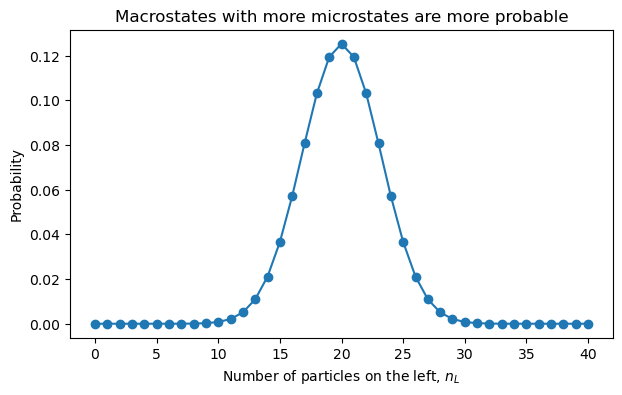

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

N = 40
n_left = np.arange(N + 1)
Omega = np.array([comb(N, n) for n in n_left], dtype=float)
prob = Omega / Omega.sum()

plt.figure(figsize=(7, 4))
plt.plot(n_left, prob, marker="o")
plt.xlabel("Number of particles on the left, $n_L$")
plt.ylabel("Probability")
plt.title("Macrostates with more microstates are more probable")
plt.show()

### Discussion Prompt

For $N=40$, almost all probability is near $n_L=N/2$. For a mole of particles, the concentration around equal partitioning is unimaginably sharper.

This is the first taste of statistical mechanics:

**Equilibrium is not usually caused by a mysterious force pushing the system toward balance. It is usually caused by the overwhelming number of microscopic ways to look balanced.**

## Thermodynamics Review: State Functions

A state function depends only on the state of the system, not on the path used to reach that state.

Important state functions include:

1. Internal energy, $E$
2. Entropy, $S$
3. Volume, $V$
4. Number of moles or particles, $n_i$ or $N_i$
5. Helmholtz free energy, $A$
6. Gibbs free energy, $G$
7. Enthalpy, $H$

Heat and work are different. They are ways of transferring energy, not properties stored in the system.

## The First Law

The first law is energy conservation applied to thermodynamic systems.

\begin{equation}
dE = \delta q + \delta w
\end{equation}

For reversible pressure-volume work and compositional changes, this is commonly written as

\begin{equation}
dE = T dS - p dV + \sum_i \mu_i dn_i
\end{equation}

This equation is one of the most important results to keep in mind today. It tells us the natural variables of internal energy:

\begin{equation}
E = E(S,V,n_1,n_2,\ldots)
\end{equation}

## Conjugate Variables

From

\begin{equation}
dE = T dS - p dV + \sum_i \mu_i dn_i
\end{equation}

we identify the conjugate variables:

\begin{align}
T &= \left(\frac{\partial E}{\partial S}\right)_{V,n} \\
-p &= \left(\frac{\partial E}{\partial V}\right)_{S,n} \\
\mu_i &= \left(\frac{\partial E}{\partial n_i}\right)_{S,V,n_{j\neq i}}
\end{align}

A useful way to say this is:

**Intensive variables are slopes of thermodynamic potentials with respect to extensive variables.**

## Activity: What Counts as Work?

For each process, decide whether energy is transferred primarily as heat, work, matter transfer, or a combination.

1. Compressing a gas with a piston.
2. Heating water on a hot plate.
3. Adding solute to a solution.
4. Stretching a rubber band.
5. Charging a capacitor.
6. Folding a protein in water.

The goal is not to memorize categories. The goal is to recognize that thermodynamics tracks energy changes through the macroscopic variables that characterize the system.

## The Second Law

For an isolated system, spontaneous changes occur in the direction of increasing entropy.

\begin{equation}
dS_{\mathrm{isolated}} \geq 0
\end{equation}

At equilibrium, entropy is maximized subject to whatever constraints define the isolated system.

This means that equilibrium can be stated as a variational principle:

\begin{align}
\delta S &= 0 \\
\delta^2 S &< 0
\end{align}

for allowed variations around a stable equilibrium state.

## Entropy as a Counting Concept

Statistical mechanics gives a molecular interpretation of entropy:

\begin{equation}
S = k_B \ln \Omega
\end{equation}

where $\Omega$ is the number of microstates compatible with the macrostate.

This equation is a compact statement of why entropy increases: unconstrained systems tend to move toward macrostates with vastly larger numbers of compatible microstates.

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/var/folders/t8/kw0bwdw15_g0pj38_ntzjgyc0000gp/T/ipykernel_64578/2731631156.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$S/k_B = \ln \Omega$")


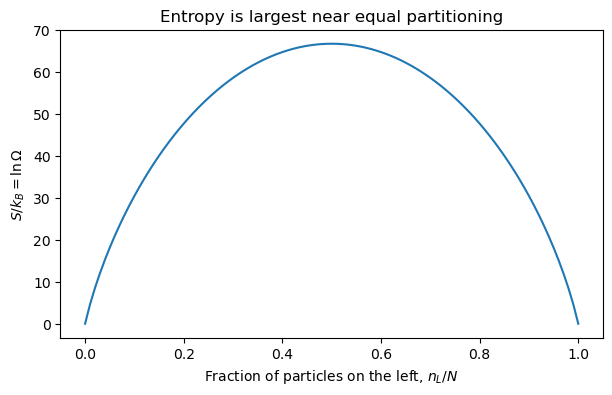

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

N = 100
n_left = np.arange(N + 1)
Omega = np.array([comb(N, n) for n in n_left], dtype=float)

# Use dimensionless entropy S/k_B = ln Omega
S_over_kB = np.log(Omega)

plt.figure(figsize=(7, 4))
plt.plot(n_left / N, S_over_kB)
plt.xlabel("Fraction of particles on the left, $n_L/N$")
plt.ylabel("$S/k_B = \ln \Omega$")
plt.title("Entropy is largest near equal partitioning")
plt.show()

## Thermal Equilibrium

Consider two subsystems that can exchange energy but not volume or particles. The total energy is fixed:

\begin{equation}
E = E^{(1)} + E^{(2)}
\end{equation}

At equilibrium, the total entropy is maximized:

\begin{equation}
S_{\mathrm{tot}} = S^{(1)}(E^{(1)}) + S^{(2)}(E^{(2)})
\end{equation}

The first-order condition is

\begin{align}
dS_{\mathrm{tot}} 
&= \left(\frac{\partial S^{(1)}}{\partial E^{(1)}}\right)dE^{(1)}
 + \left(\frac{\partial S^{(2)}}{\partial E^{(2)}}\right)dE^{(2)} \\
&= \left(\frac{1}{T^{(1)}} - \frac{1}{T^{(2)}}\right)dE^{(1)}
\end{align}

Since $dE^{(2)}=-dE^{(1)}$, equilibrium requires

\begin{equation}
T^{(1)} = T^{(2)}
\end{equation}

## Why Heat Flows from Hot to Cold

If $T^{(1)} > T^{(2)}$, then $1/T^{(1)} < 1/T^{(2)}$. A transfer of energy from system 1 to system 2 increases total entropy.

This is a good moment to emphasize an important idea:

**Temperature is not defined as average kinetic energy in thermodynamics. It is defined by the entropy derivative.**

\begin{equation}
\frac{1}{T} = \left(\frac{\partial S}{\partial E}\right)_{V,n}
\end{equation}

The kinetic interpretation emerges later for ideal gases and related models.

## Mechanical and Chemical Equilibrium

The same entropy maximization logic gives the other equilibrium conditions.

For two subsystems that can exchange volume:

\begin{equation}
p^{(1)} = p^{(2)}
\end{equation}

For two subsystems that can exchange particles of species $i$:

\begin{equation}
\mu_i^{(1)} = \mu_i^{(2)}
\end{equation}

So equilibrium means equality of the intensive variables associated with the allowed exchanges:

1. Energy exchange $\rightarrow$ equal temperature.
2. Volume exchange $\rightarrow$ equal pressure.
3. Matter exchange $\rightarrow$ equal chemical potential.

## Free Energies: Why Do We Need Them?

The entropy maximum principle is cleanest for isolated systems with fixed $E$, $V$, and $N$.

But in the lab, we often control different variables:

1. Fixed $T,V,N$: useful for molecular simulations and canonical ensembles.
2. Fixed $T,p,N$: common for chemistry and biology in open atmospheric conditions.
3. Fixed $S,p,N$: useful for enthalpy.

Free energies are created to make the thermodynamic potential match the variables we control.

## Legendre Transform to the Helmholtz Free Energy

If we control $T$ rather than $S$, we transform from $E(S,V,n)$ to the Helmholtz free energy:

\begin{equation}
A = E - TS
\end{equation}

Its differential is

\begin{align}
dA &= dE - T dS - S dT \\
&= -S dT - p dV + \sum_i \mu_i dn_i
\end{align}

Therefore,

\begin{equation}
A = A(T,V,n_1,n_2,\ldots)
\end{equation}

At constant $T,V,n$, stable equilibrium minimizes $A$.

## Gibbs Free Energy and Enthalpy

The enthalpy is

\begin{equation}
H = E + pV
\end{equation}

with differential

\begin{equation}
dH = T dS + V dp + \sum_i \mu_i dn_i
\end{equation}

The Gibbs free energy is

\begin{equation}
G = E - TS + pV
\end{equation}

with differential

\begin{equation}
dG = -S dT + V dp + \sum_i \mu_i dn_i
\end{equation}

At constant $T,p,n$, stable equilibrium minimizes $G$. This is why $\Delta G$ appears so often in chemistry.

## Quick Reference: Natural Variables

| Potential | Definition | Differential | Natural variables | Equilibrium criterion |
|---|---:|---:|---:|---:|
| $E$ | $E$ | $dE=T dS-p dV+\sum_i\mu_i dn_i$ | $S,V,n$ | minimize $E$ at fixed $S,V,n$ |
| $A$ | $E-TS$ | $dA=-S dT-p dV+\sum_i\mu_i dn_i$ | $T,V,n$ | minimize $A$ at fixed $T,V,n$ |
| $H$ | $E+pV$ | $dH=T dS+V dp+\sum_i\mu_i dn_i$ | $S,p,n$ | minimize $H$ at fixed $S,p,n$ |
| $G$ | $E-TS+pV$ | $dG=-S dT+V dp+\sum_i\mu_i dn_i$ | $T,p,n$ | minimize $G$ at fixed $T,p,n$ |

## Maxwell Relations

Because thermodynamic potentials are state functions, their mixed second derivatives are equal. For example, from

\begin{equation}
dA = -S dT - p dV
\end{equation}

we identify

\begin{align}
S &= -\left(\frac{\partial A}{\partial T}\right)_V \\
p &= -\left(\frac{\partial A}{\partial V}\right)_T
\end{align}

Taking mixed derivatives gives

\begin{equation}
\left(\frac{\partial S}{\partial V}\right)_T =
\left(\frac{\partial p}{\partial T}\right)_V
\end{equation}

Maxwell relations are useful because they connect quantities that may be hard to measure to quantities that may be easier to measure.

## Extensive and Intensive Variables

Extensive variables scale with system size:

\begin{equation}
E(\lambda S, \lambda V, \lambda n) = \lambda E(S,V,n)
\end{equation}

Examples include $E$, $S$, $V$, and $n_i$.

Intensive variables do not scale with system size. Examples include $T$, $p$, and $\mu_i$.

For a one-component system, extensivity leads to the Euler relation:

\begin{equation}
E = TS - pV + \mu n
\end{equation}

and the Gibbs-Duhem relation:

\begin{equation}
S dT - V dp + n d\mu = 0
\end{equation}

## Demonstration: Free Energy Minima

For a system at fixed $T,V,N$, the equilibrium state minimizes $A$. The exact free energy surface depends on the system, but the qualitative idea is simple: stable states correspond to minima of an appropriate thermodynamic potential.

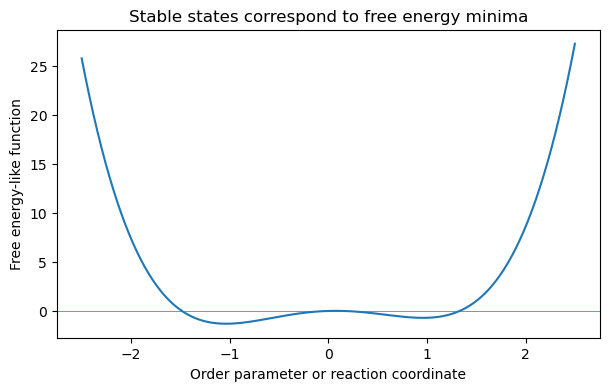

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2.5, 2.5, 500)

# A simple one-dimensional free energy-like function
A = x**4 - 2*x**2 + 0.3*x

plt.figure(figsize=(7, 4))
plt.plot(x, A)
plt.xlabel("Order parameter or reaction coordinate")
plt.ylabel("Free energy-like function")
plt.title("Stable states correspond to free energy minima")
plt.axhline(0, linewidth=0.5)
plt.show()

## Connecting Back to Statistical Mechanics

Thermodynamics tells us what variables matter and what must be true at equilibrium. Statistical mechanics tells us **why** those relationships hold and how to compute thermodynamic quantities from microscopic models.

Preview of the next few meetings:

1. Conditions of equilibrium and stability: what exactly does "stable" mean?
2. Ensembles: how do we represent many possible microscopic states?
3. Partition functions: how do probabilities and thermodynamic potentials come from microscopic energies?
4. Applications: non-interacting systems, phase transitions, Monte Carlo, and fluids.

## Exit Questions

Ask students to answer these before leaving:

1. In one sentence, what is statistical mechanics?
2. What is the difference between a microstate and a macrostate?
3. Why does entropy increase for an isolated system?
4. What variables are held fixed when $A$ is minimized?
5. What variables are held fixed when $G$ is minimized?
6. What is one question from your research that statistical mechanics might help answer?

## Reading for Next Time

Read Chandler Chapter 2, Sections 2.1--2.4.

Focus on these questions:

1. How do the equilibrium conditions $T^{(1)}=T^{(2)}$, $p^{(1)}=p^{(2)}$, and $\mu_i^{(1)}=\mu_i^{(2)}$ emerge from variational arguments?
2. What does stability mean mathematically?
3. Why do second derivatives of thermodynamic potentials matter?
4. How do phase boundaries arise from equality of chemical potentials?